In [1]:
import copy
import glob
import json
import random
from copy import deepcopy as dc
from os.path import join as opj

import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pingouin as pg
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap, Normalize
from scipy.stats import spearmanr

from cloth_fmri.config.config import CONFIG
from cloth_fmri.models.model_predictions import (woven_stiff_pred, cnn_stiff_pred, 
                                                 vjepa2_stiff_pred, vivit_stiff_pred, videomae_stiff_pred)
from cloth_fmri.utils.rdm import (
    build_model_rdm_from_stiffness_predictions,
    build_rdm,
    upper_to_square_rdm,
)
from cloth_fmri.utils.stats import (
    bootstrap_sample,
    get_mode_value,
    bootstrap_cor,
    calc_p,
)

from cloth_fmri.utils.plot import (
    plot_bootstrap_violin,
    plot_model_rdm_matrix,
    plot_rdm_heatmap_from_upper,
    plot_two_distribution_violin,
)


random.seed(9)

models = ["woven", "vjepa2", "videomae", "vivit", "cnn"]
c_ls = ["0.1", "1.0", "10.0", "100.0"]
SUBJECT_LIST = CONFIG["subjects"]
SCENES = CONFIG['scenes']
ROIS = ["tower", "v1"]

human_rdm_root_dir = opj(CONFIG["output_root"], "analysis", "fig4")

bootn = 10000

/gpfs/milgram/project/yildirim/wb338/conda_envs/mybrainiak/lib/python3.7/site-packages/outdated/utils.py:18: OutdatedPackageWarning: The package pingouin is out of date. Your version is 0.5.3, the latest is 0.6.1.
Set the environment variable OUTDATED_IGNORE=1 to disable these warnings.
  **kwargs


In [2]:
# ----------------------------------------------------
# Build model RDMs
# ----------------------------------------------------
model_pred_dict = {
    "woven": woven_stiff_pred,
    "vjepa2": vjepa2_stiff_pred,
    "videomae": videomae_stiff_pred,
    "vivit": vivit_stiff_pred,
    "cnn": cnn_stiff_pred,
}

models_rdm = {}

for model in models:
    rdm_vec, rdm_full = build_model_rdm_from_stiffness_predictions(
        model_pred_dict[model],
        SCENES,
    )
    models_rdm[model] = rdm_vec


In [3]:
# ----------------------------------------------------
# Containers
# ----------------------------------------------------
best_r = {
    roi: {model: [] for model in models}
    for roi in ROIS
}

best_bootstrap_r = {
    roi: {model: [] for model in models}
    for roi in ROIS
}

best_human_rdm = {}
best_split_half = {}


# ----------------------------------------------------
# Search best human RDM and compute model correlations
# ----------------------------------------------------
for roi in ROIS:
    best_split_half_cor = -1.0
    best_split_half_p = None
    best_bootstrap_correlation = None
    best_rdm_avg_all_subs = None

    best_mean_r = {
        model: None
        for model in models
    }

    best_bootstrap_p = {
        model: None
        for model in models
    }

    for c in c_ls:
        cur_human_rdm_dir = opj(human_rdm_root_dir, roi, f"C={c}")

        matching_files = glob.glob(f"{cur_human_rdm_dir}/*.json*")

        if len(matching_files) == 0:
            continue

        flag = True

        for file in matching_files:
            with open(file, "r") as f:
                data = json.load(f)

            if flag:
                flag = False
                all_data = copy.deepcopy(data)

                for key_sub in all_data.keys():
                    for key_scene in all_data[key_sub].keys():
                        all_data[key_sub][key_scene] = [
                            all_data[key_sub][key_scene]
                        ]

            else:
                for key_sub in all_data.keys():
                    for key_scene in all_data[key_sub].keys():
                        all_data[key_sub][key_scene].append(
                            data[key_sub][key_scene]
                        )

        # ----------------------------------------------------
        # Average over iterations using mode
        # ----------------------------------------------------
        all_data_mean = copy.deepcopy(all_data)

        for key_sub in all_data.keys():
            for key_scene in all_data[key_sub].keys():
                all_data_mean[key_sub][key_scene] = get_mode_value(
                    all_data[key_sub][key_scene]
                )

        # ----------------------------------------------------
        # Subject-level RDM and model correlations
        # ----------------------------------------------------
        rdm_all_subs = {}
        r_model = {
            model: {}
            for model in models
        }

        for sub in SUBJECT_LIST:
            if sub in all_data_mean:
                rdm_all_subs[sub] = build_rdm(
                    all_data_mean[sub],
                    SCENES,
                    plot=False,
                )

                for model in models:
                    r_model[model][sub] = spearmanr(
                        models_rdm[model],
                        rdm_all_subs[sub],
                    )[0]

        rdm_avg_all_subs = np.mean(
            np.array(list(rdm_all_subs.values())),
            axis=0,
        )

        mean_r = {
            model: round(np.mean(list(r_model[model].values())), 3)
            for model in models
        }

        # ----------------------------------------------------
        # Bootstrap model correlations
        # ----------------------------------------------------
        bootstrap_r = {}

        for model in models:
            bootstrap_r[model] = [
                np.mean(bootstrap_sample(list(r_model[model].values())))
                for _ in range(bootn)
            ]

        bootstrap_p = {
            model: calc_p(bootstrap_r[model])
            for model in models
        }

        # ----------------------------------------------------
        # Split-half reliability
        # ----------------------------------------------------
        my_split_half_data = np.array(list(rdm_all_subs.values()))

        split_half_cor, split_half_p, bootstrap_correlations = bootstrap_cor(
            my_split_half_data,
            seed=0,
        )

        if split_half_cor >= best_split_half_cor:
            best_split_half_cor = split_half_cor
            best_split_half_p = split_half_p

            best_bootstrap_correlation = dc(bootstrap_correlations)
            best_rdm_avg_all_subs = dc(rdm_avg_all_subs)

            for model in models:
                best_mean_r[model] = mean_r[model]
                best_bootstrap_p[model] = bootstrap_p[model]

                best_r[roi][model] = list(r_model[model].values())
                best_bootstrap_r[roi][model] = dc(bootstrap_r[model])

    # ----------------------------------------------------
    # Save best result
    # ----------------------------------------------------
    best_human_rdm[roi] = dc(best_rdm_avg_all_subs)

    best_split_half[roi] = {
        "r": best_split_half_cor,
        "p": best_split_half_p,
        "bootstrap": dc(best_bootstrap_correlation),
    }

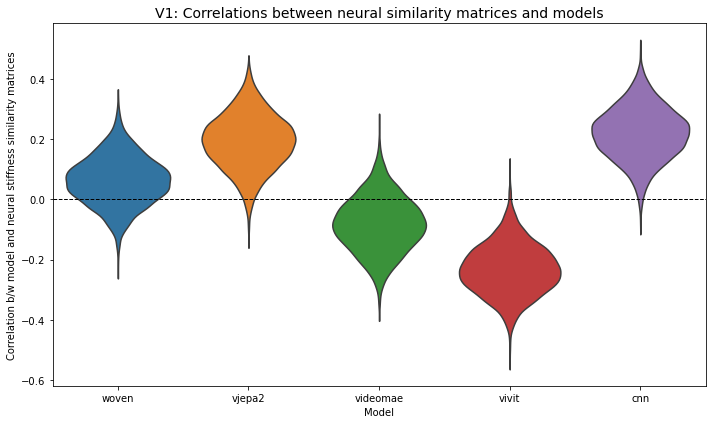

In [4]:
# ----------------------------------------------------
# Plot RDM-model correlations: one figure per ROI
# ----------------------------------------------------

roi_name_map = {
    "tower": "Physics ROI",
    "v1": "V1",
}


for roi in ['v1']: #ROIS:

    plot_rows = []

    for model in models:
        for r in best_bootstrap_r[roi][model]:
            plot_rows.append({
                "Model": model,
                "Spearman r": r,
            })

    plot_df = pd.DataFrame(plot_rows)

    fig, ax = plt.subplots(figsize=(10, 6))

    sns.violinplot(
        data=plot_df,
        x="Model",
        y="Spearman r",
        order=models,
        inner=None,
        cut=0,
        ax=ax,
    )

    ax.axhline(
        y=0.0,
        color="black",
        linestyle="--",
        linewidth=1,
    )


    ax.set_title(
        f"{roi_name_map[roi]}: Correlations between neural similarity matrices and models",
        fontsize=14,
    )
    ax.set_xlabel("Model")
    ax.set_ylabel("Correlation b/w model and neural stiffness similarity matrices")

    plt.tight_layout()
    plt.show()